# PART6_Validate_with_breeding_lines
Validate genomic prediction model using breeding lines

In [7]:
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import ElasticNet

from modules.make_data_for_prediction import make_data
from modules.make_Haplotype_block import make_Haplotype_block_other_pop

# basic variables
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV = 5
model = "Enet"

# make Haplotype Block genotype of Breeding line

In [ ]:
other_genotype = "../data/genotype_data/Breeding_line_2020_genotype.txt"
NAM_HB_genotype = "../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv"
family_list = "../data/family_list.csv"
breeding_line_HB_genotype = make_Haplotype_block_other_pop(other_genotype, NAM_HB_genotype, family_list)
breeding_line_HB_genotype.to_csv("../data/PART6_Validate_with_breeding_lines/Haplotype_breeding_line_LD90.csv", index=None)

## Extract important HBs of Breeding_line genotype

In [3]:
# extract best model and HB num
with open('../data/PART5_Select_HBs/Compare_models_by_all_RILs_selected_HBs.pic.bin', 'rb') as p:
    summary = pickle.load(p)
summary = pd.DataFrame(summary)

In [4]:
# extract important HBs
Breeding_line_genotype = pd.read_csv("../data/PART6_Validate_with_breeding_lines/Haplotype_breeding_line_LD90.csv")

# each trait
for trait_name in ["LW_mean", "GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    
    # select best HB_num and model
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    trait_summary = trait_summary.groupby(["HB_num", "model"]).mean().reset_index()
    HB_num = trait_summary.sort_values(by="r", ascending=False).iloc[0, 0]
    
    # extract feature importances
    with open('../data/PART5_Build_application_model/Compare_models_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        summary_all_HB = pickle.load(p)
    summary_all_HB = pd.DataFrame(summary_all_HB)
    
    path = "../data/PART6_Validate_with_breeding_lines/{}_{}_{}_Breeding_line.csv".format(trait_name, model, HB_num)                
    imp = np.mean(summary_all_HB.loc[(summary_all_HB.iloc[:, 0] == trait_name) & (summary_all_HB.iloc[:, 2] == model), 6].values, axis=0)
    high_imp_index = np.sort(np.argsort(np.abs(imp))[::-1][:HB_num])
    Breeding_line_genotype.loc[high_imp_index, :].to_csv(path, index=None)

# Prediction accuracy by best model for Breeding lines

LW_mean Enet 800
CV0
CV1
CV2
CV3
CV4
0.9193256366337552


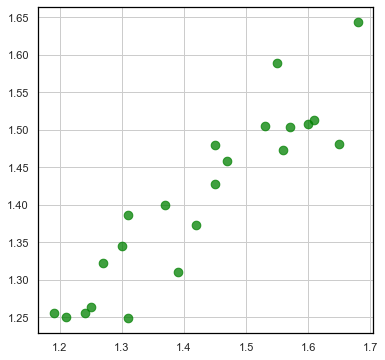

GN_mean Enet 900
CV0
CV1
CV2
CV3
CV4
0.9006668551190743


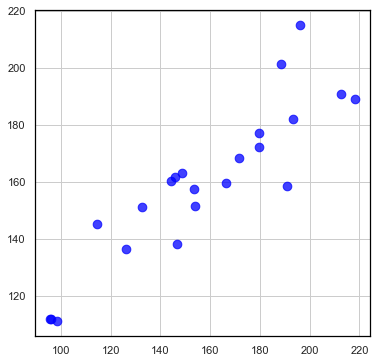

PN_mean Enet 1000
CV0
CV1
CV2
CV3
CV4
0.8786439489513653


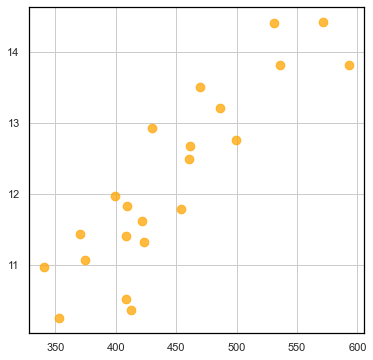

Area.size.AS..mm2. Enet 600
CV0
CV1
CV2
CV3
CV4
0.6846208652611037


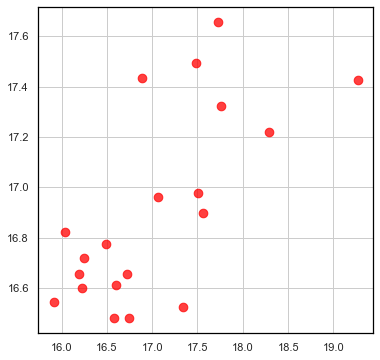

In [5]:
Breeding_line_phenotypes = pd.read_csv("../data/PART6_Validate_with_breeding_lines/Breeding_line_observed_phenotype_2020.csv", index_col=0)

# each trait
for i in [["LW_mean", "green"], ["GN_mean", "blue"], ["PN_mean", "orange"], ["Area.size.AS..mm2.", "red"]]:
    trait_name = i[0]
    color = i[1]
    # select best HB_num and model
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    trait_summary = trait_summary.groupby(["HB_num", "model"]).mean().reset_index()
    HB_num = trait_summary.sort_values(by="r", ascending=False).iloc[0, 0]
    print(trait_name, model, HB_num)
    
    # make training dataset
    genotype = "../data/PART5_Build_application_model/selected_genotype/{}_{}_{}.csv".format(trait_name, model, HB_num)    
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False, log=False)
    
    # make Breeding_line genotype dataset
    Breeding_line_genotype = pd.read_csv("../data/PART6_Validate_with_breeding_lines/{}_{}_{}_Breeding_line.csv".format(trait_name, model, HB_num)).iloc[:, 3:]
    Breeding_line_genotype["Hitomebore"] = 0
    Breeding_line_genotype = Breeding_line_genotype.fillna(0).T
    
    Breeding_line_preds = []
    
    # each CV
    for i in range(CV):
        print("CV{}".format(i))
        
        # parameters
        if model != 'GBLUP':
            params = pd.read_csv("../data/PART5_Build_application_model/{}_selected_HBs_{}_params.csv".format(model, trait_name), index_col=0)
            params.columns = ["trait", "HB_num", "CV", "params"]
            params = ast.literal_eval(params.loc[(params["trait"] == trait_name) & (params["CV"] == i) & (params["HB_num"] == HB_num), "params"].values[0])
        
        # train data of each CV
        tmp_train_data = train_data[i]
        X_train = tmp_train_data[0].fillna(0)
        y_train = tmp_train_data[1]
        
        # train model
        clf = ElasticNet(alpha=params["alpha"], l1_ratio=params["l1_ratio"], max_iter=100000)
        clf.fit(X_train, y_train)
        
        # predict breeding lines
        Breeding_line_pred = clf.predict(Breeding_line_genotype)
        Breeding_line_preds.append(Breeding_line_pred)
    
    # average predicted values from CV1~5
    Breeding_line_preds = np.mean(Breeding_line_preds, axis=0)
    Breeding_line_obs = Breeding_line_phenotypes[trait_name].values
    
    # calculate r between predicted & observed values of breeding lines
    scatter_data = pd.DataFrame({"y":Breeding_line_obs, "pred":Breeding_line_preds, "line":Breeding_line_phenotypes.index.values})
    scatter_data = scatter_data.dropna()
    print(np.corrcoef([scatter_data.y, scatter_data.pred])[0,1])
    
    # visualize predicted & observed values of breeding lines
    sns.set_style('whitegrid')
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(data=scatter_data, x="y", y="pred", s=75, color=color, linewidth=1, alpha=0.75)
    min_val = min(min(Breeding_line_obs), min(Breeding_line_preds))
    max_val = max(max(Breeding_line_obs), max(Breeding_line_preds))
    for sp in ["top", "left", "right", "bottom"]:
        ax.spines[sp].set_color('black')
    plt.show()